# 年度回报（2004-2024）- 分类表格与折线图

本Notebook从 `output/annual_returns_2014_2024.md` 解析各分类表格，绘制每个分类的折线图（各资产为多条曲线），并展示对应表格。

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path('..').resolve()
md_path = ROOT / 'output' / 'annual_returns_2014_2024.md'
assert md_path.exists(), md_path

def parse_md_tables(md_path: Path):
    lines = md_path.read_text(encoding='utf-8').splitlines()
    out = []
    current = None
    i = 0
    while i < len(lines):
        ln = lines[i].strip()
        if ln.startswith('### '):
            current = ln[4:].strip()
            i += 1
            continue
        if current and ln.startswith('| 资产 |'):
            tbl = []
            while i < len(lines) and lines[i].strip():
                tbl.append(lines[i].strip())
                i += 1
            if len(tbl) >= 2:
                headers = [h.strip() for h in tbl[0].strip('|').split('|')]
                rows = []
                for tl in tbl[2:]:
                    toks = [t.strip() for t in tl.strip('|').split('|')]
                    if len(toks) == len(headers):
                        rows.append(toks)
                df = pd.DataFrame(rows, columns=headers).set_index('资产')
                for c in df.columns:
                    df[c] = df[c].astype(str).str.replace('%','', regex=False).replace({'': np.nan}).astype(float)
                out.append((current, df))
            continue
        i += 1
    return out

cats = parse_md_tables(md_path)
len(cats), [c for c,_ in cats]

/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/416467467.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c] = df[c].astype(str).str.replace('%','', regex=False).replace({'': np.nan}).astype(float)
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/416467467.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c] = df[c].astype(str).str.replace('%','', regex=False).replace({'': np.nan}).astype(float)
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/416467467.py:37: FutureWa

(7,
 ['A股宽基指数 年度回报率',
  '风格/规模指数 年度回报率',
  '申万一级行业 年度回报率',
  '特色A股指数 年度回报率',
  '各类债券指数 年度回报率',
  '大宗商品指标 年度回报率',
  '海外指数/ETF 年度回报率'])

,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
资产,,,,,,,,,,,,,,,,,,,,,
沪深300,-16.3,-7.65,121.02,161.55,-65.95,96.71,-12.51,-25.01,7.55,-7.65,...,5.58,-11.28,21.78,-25.31,36.07,27.21,-5.20,-21.63,-11.38,14.68
中证500,NaN,NaN,100.68,186.63,-60.80,131.27,10.07,-33.83,0.28,16.89,...,43.12,-17.78,-0.20,-33.32,26.38,20.87,15.58,-20.31,-7.42,5.46
中证1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,76.10,-20.01,-17.35,-36.87,25.67,19.39,20.52,-21.58,-6.28,1.20


/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 23485 (\N{CJK UNIFIED IDEOGRAPH-5BBD}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/i

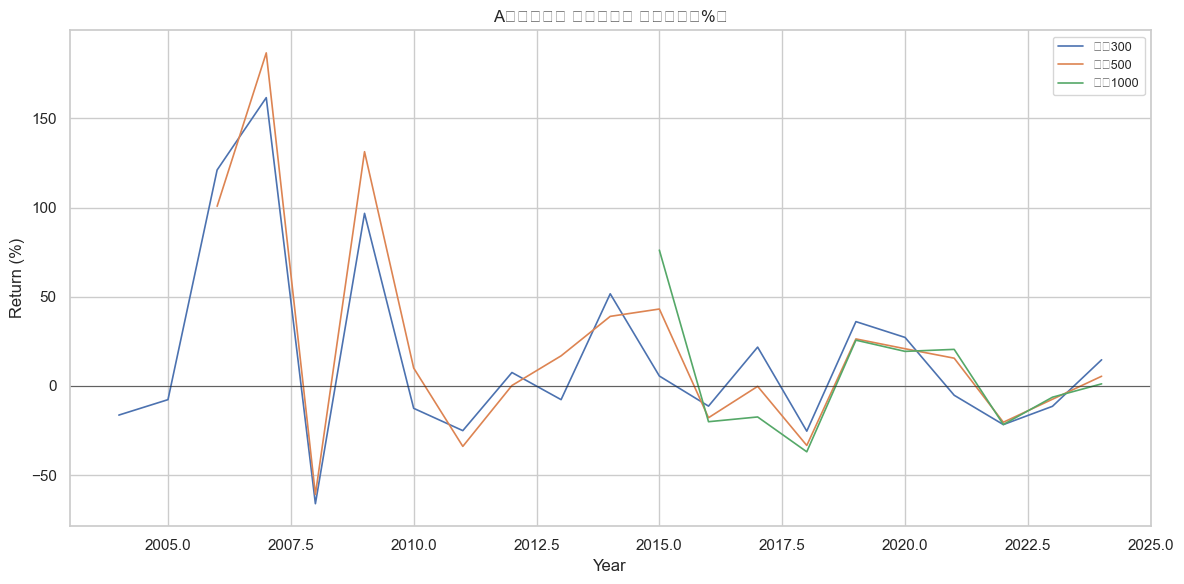

,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
资产,,,,,,,,,,,,,,,,,,,,,
红利指数(上证),NaN,NaN,100.75,160.59,-68.93,94.33,-22.41,-18.47,7.06,-11.78,...,9.31,-7.57,16.31,-16.96,10.67,-5.69,7.62,-2.42,2.67,14.45
全指成长,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.83,11.45,-10.37,...,6.30,-8.95,26.49,-24.10,42.73,38.02,-8.39,-24.70,-20.00,0.87
创质量,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-26.71,-20.59,3.01
超大盘,NaN,NaN,NaN,NaN,NaN,NaN,-26.76,-19.63,15.28,-22.88,...,-1.95,0.29,17.25,-18.98,26.60,12.33,-9.37,-20.25,-12.82,18.50
上证小盘,NaN,NaN,NaN,NaN,NaN,NaN,9.81,-30.42,-2.84,10.38,...,35.76,-18.15,0.50,-31.12,22.89,17.84,17.66,-15.35,-5.24,4.98
中小盘(深证),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,39.96,-20.14,-3.71,-33.18,30.60,24.75,11.33,-21.82,-9.56,6.55
中证A500,NaN,NaN,117.07,163.29,-64.50,96.71,-7.78,-26.14,5.78,-0.08,...,15.79,-13.20,20.44,-27.00,36.00,31.29,0.61,-22.56,-11.42,12.98
创业板指,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-35.88,-2.14,82.73,...,84.41,-27.71,-10.67,-28.65,43.79,64.96,12.02,-29.37,-19.41,13.23
创业板50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,84.43,-31.62,-14.39,-34.09,50.93,88.74,16.88,-29.83,-24.00,21.07


/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 35268 (\N{CJK UNIFIED IDEOGRAPH-89C4}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/i

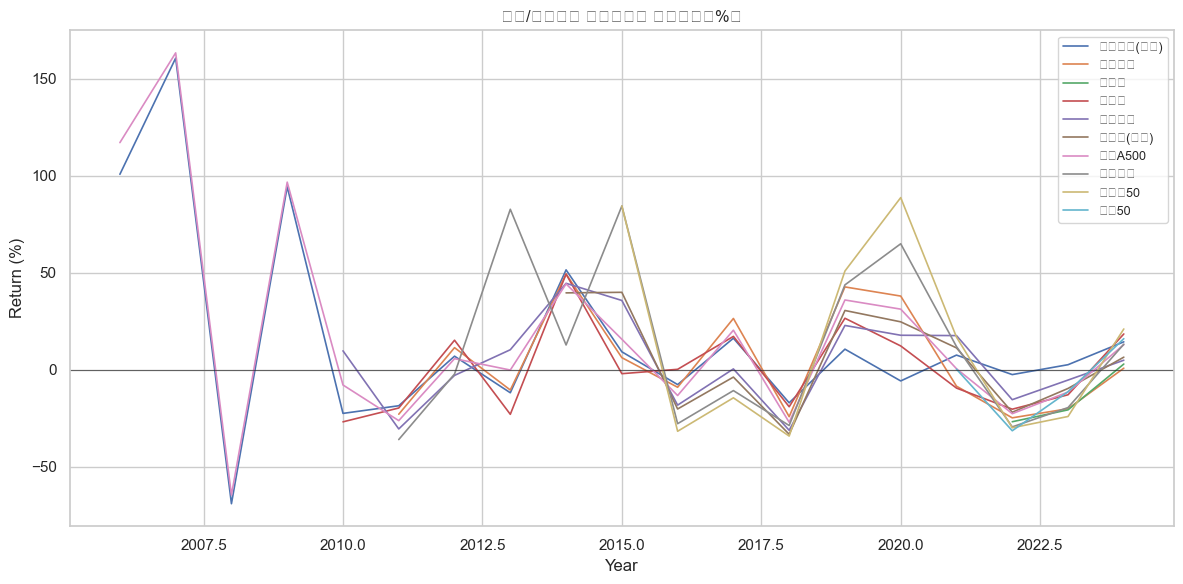

,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
资产,,,,,,,,,,,,,,,,,,,,,
农林牧渔,-22.96,-15.06,82.54,162.07,-46.51,91.16,21.06,-31.18,-5.05,17.29,...,66.77,-8.58,-12.62,-22.44,45.45,18.29,-4.93,-11.43,-13.13,-11.58
基础化工,-11.95,-10.08,89.45,184.93,-64.68,110.87,-22.40,-31.06,0.28,6.54,...,55.01,-7.13,-3.81,-31.72,24.22,34.98,37.19,-19.08,-14.69,-5.09
钢铁,-8.13,-17.88,111.89,174.59,-70.88,96.16,-28.32,-28.24,-4.78,-17.27,...,1.80,-8.13,19.74,-29.62,-2.09,4.90,34.06,-23.78,-8.18,0.16
有色金属,-20.62,-8.32,144.07,262.55,-77.30,180.03,22.10,-41.81,13.64,-29.64,...,15.38,-6.17,15.39,-41.04,24.27,34.77,40.47,-20.31,-8.70,3.19
电子,-6.77,-26.73,41.90,131.30,-65.63,145.16,39.38,-41.38,-0.74,42.78,...,71.97,-12.70,13.47,-42.37,73.77,36.05,16.04,-36.54,7.25,18.52
汽车,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,46.90,-9.53,-0.52,-34.34,14.60,45.85,17.20,-20.13,3.29,16.34
家用电器,-19.67,-12.08,71.94,202.56,-55.44,153.84,-0.02,-24.76,15.84,39.33,...,42.73,-1.87,43.03,-31.40,56.99,31.08,-19.54,-20.95,3.77,25.44
食品饮料,-12.51,6.31,171.03,124.76,-58.70,109.87,20.81,-10.37,-0.74,-7.36,...,26.58,7.43,53.85,-21.95,72.87,84.97,-6.01,-15.12,-14.94,-8.03
纺织服饰,-19.41,-24.29,63.47,185.34,-62.68,119.11,7.51,-25.52,-10.15,8.16,...,89.17,-13.56,-23.85,-34.33,7.09,-7.08,3.39,-14.66,0.34,-5.32


/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 30003 (\N{CJK UNIFIED IDEOGRAPH-7533}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 19975 (\N{CJK UNIFIED IDEOGRAPH-4E07}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 32423 (\N{CJK UNIFIED IDEOGRAPH-7EA7}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/i

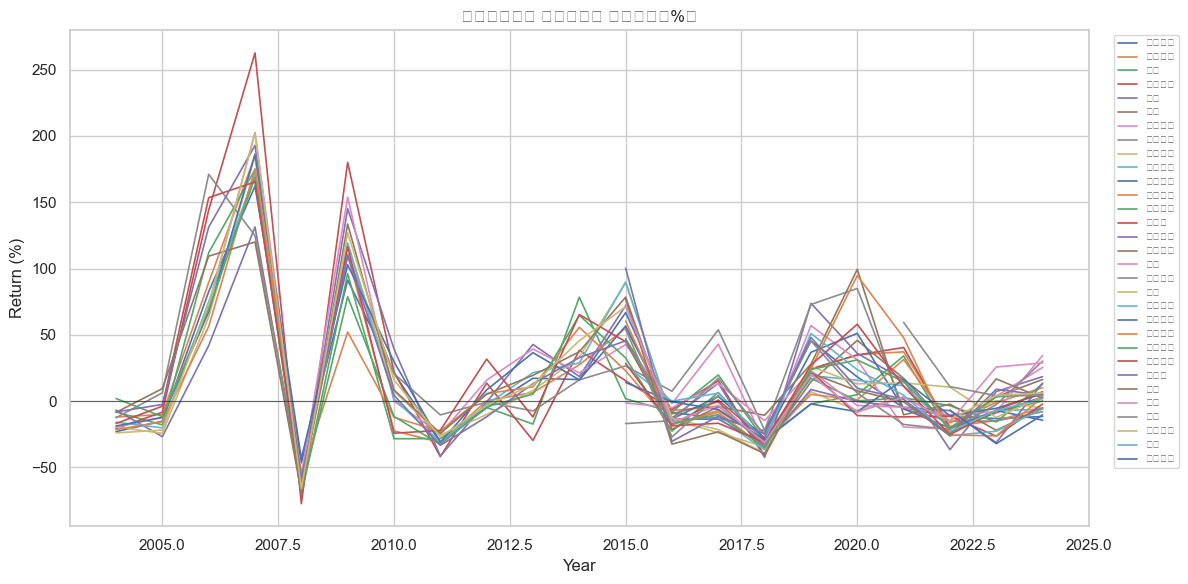

,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
资产,,,,,,,,,,,,,,,,,,,,,
中证2000(CSI),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,109.78,-7.63,-24.1,-33.34,21.96,15.39,25.89,-14.77,5.57,-2.14
国证2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,88.14,-12.14,-16.9,-33.77,23.45,16.87,29.19,-17.20,-1.16,-0.73


/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/i

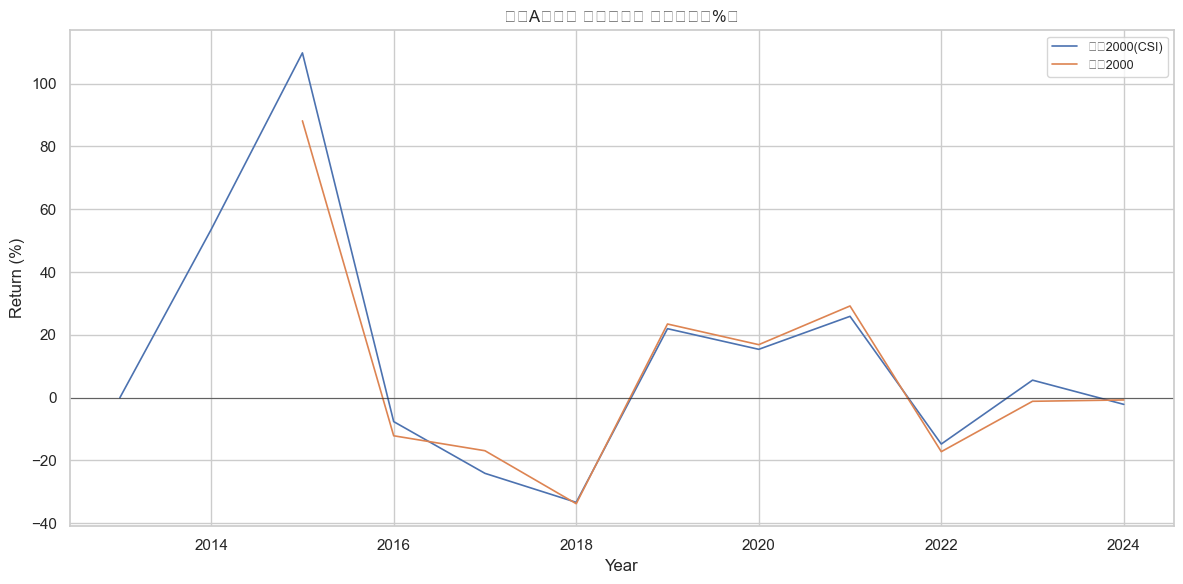

,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
资产,,,,,,,,,,,,,,,,,,,,,
国债指数(上证),-3.81,14.06,2.14,-0.46,9.40,0.87,3.21,4.05,3.35,2.75,...,6.09,3.39,0.67,5.62,4.35,3.67,4.24,3.62,3.79,8.04
沪公司债,NaN,NaN,NaN,NaN,NaN,1.82,8.49,3.37,7.86,2.89,...,9.03,4.78,1.37,5.72,5.47,4.26,3.68,3.27,3.54,5.14
深信用债,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.77,4.98,2.36,4.63,5.66,4.10,3.61,3.04,4.18,4.51
深公司债,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.75,5.08,2.34,4.52,5.89,4.13,3.50,2.49,4.07,4.97
企债指数(深证),-2.99,23.65,0.83,-6.59,16.26,-4.07,2.23,-2.47,1.57,-1.81,...,2.43,0.50,-3.02,0.22,0.31,-0.41,-0.57,-0.38,0.05,1.09
国证转债,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-25.65,-11.71,-0.25,-1.24,25.06,4.82,18.67,-10.10,-0.50,5.91
上证转债,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.95,...,-31.26,-11.36,0.62,-0.10,21.71,1.72,13.81,-8.49,0.08,7.37
深证转债,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.10,-12.37,-6.10,-5.25,32.16,14.55,26.87,-13.21,-1.39,3.44
深转交债,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,14.01,26.48,-14.21,-1.11,3.11


/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 20538 (\N{CJK UNIFIED IDEOGRAPH-503A}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 21048 (\N{CJK UNIFIED IDEOGRAPH-5238}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/i

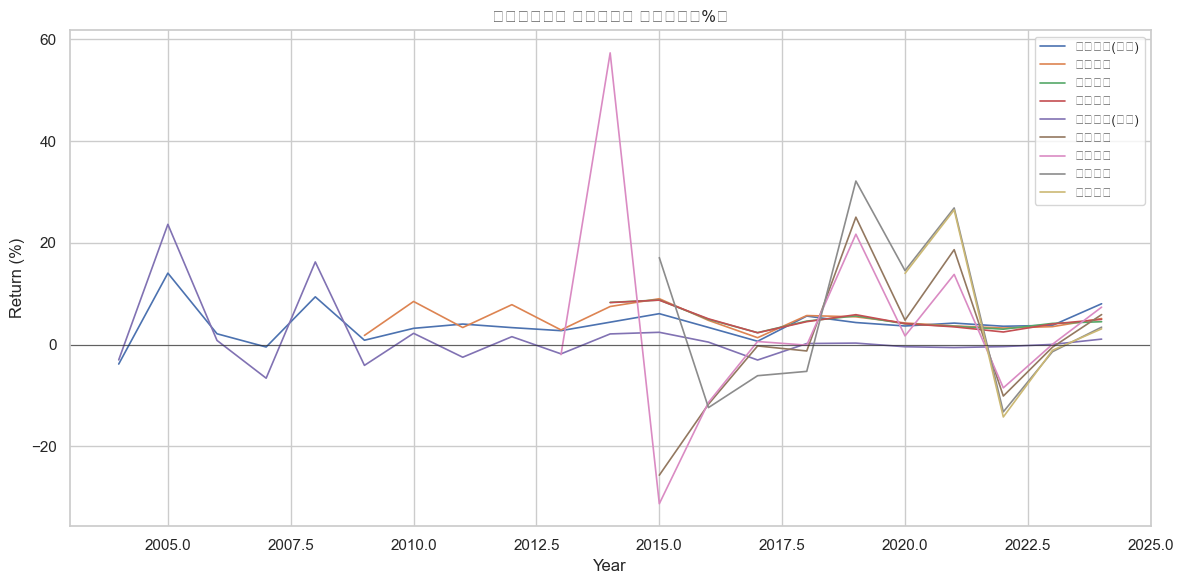

,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
资产,,,,,,,,,,,,,,,,,,,,,
黄金(SGE基准价),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.42,3.78,20.57,14.61,-4.73,9.75,17.17,28.14
有色金属(申万801050),-20.62,-8.32,144.07,262.55,-77.30,180.03,22.10,-41.81,13.64,-29.64,...,15.38,-6.17,15.39,-41.04,24.27,34.77,40.47,-20.31,-8.70,3.19
豆粕主力连续(M0),NaN,NaN,3.18,42.17,-27.34,21.82,13.91,-14.22,11.01,2.81,...,-17.04,17.77,-1.50,-4.93,5.60,25.51,-8.34,23.42,-15.83,-18.62


/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 23447 (\N{CJK UNIFIED IDEOGRAPH-5B97}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 21830 (\N{CJK UNIFIED IDEOGRAPH-5546}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 21697 (\N{CJK UNIFIED IDEOGRAPH-54C1}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/i

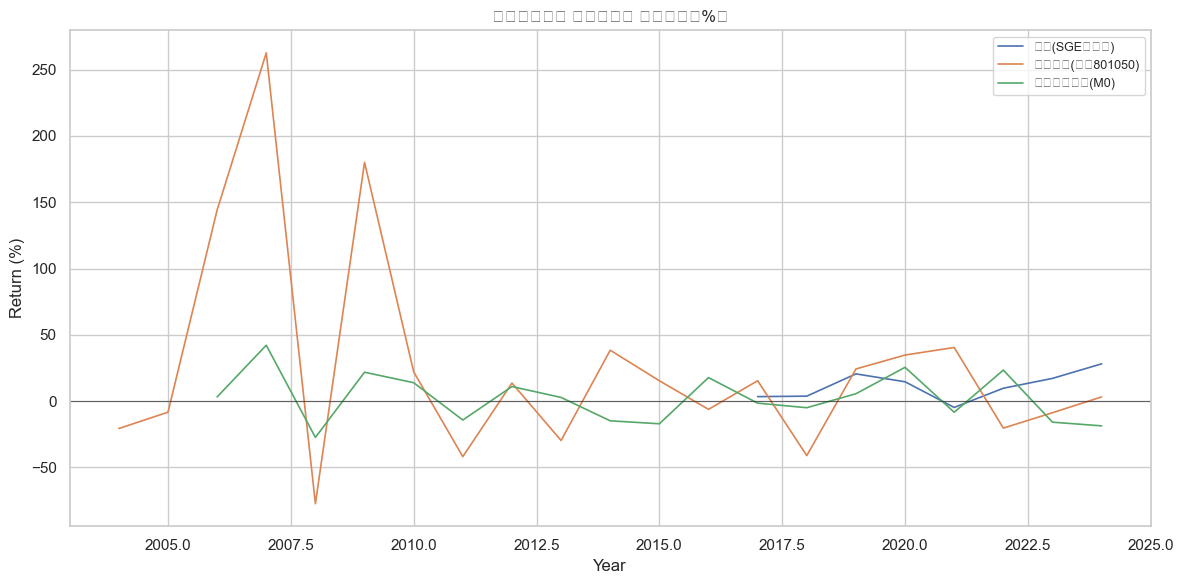

,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
资产,,,,,,,,,,,,,,,,,,,,,
标普500(SPY.US),NaN,NaN,13.71,3.26,-38.28,23.48,12.83,1.90,16.01,32.33,...,1.23,11.98,21.71,-4.57,31.22,18.34,28.73,-18.17,26.18,24.89
纳指100(QQQ.US),10.55,1.57,7.15,19.01,-41.72,54.70,19.91,3.52,18.12,36.64,...,9.41,7.10,32.66,-0.11,38.96,48.65,27.42,-32.58,54.77,25.58
德国ETF(EWG.US),NaN,NaN,32.45,31.74,-45.76,16.73,6.69,-17.66,32.30,30.84,...,-2.79,3.62,27.40,-21.40,19.16,9.70,5.72,-22.30,20.06,7.17
印度ETF(INDA.US),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.60,...,-7.49,-1.64,36.07,-7.38,6.49,14.84,21.35,-8.94,16.94,7.85
罗素2000(IWM.US),NaN,NaN,16.95,-2.71,-35.14,26.81,25.31,-4.42,16.70,38.66,...,-4.54,21.61,14.60,-11.12,25.36,20.04,14.54,-20.85,15.11,10.09
越南ETF(VNM.US),NaN,NaN,NaN,NaN,NaN,NaN,2.70,-43.83,26.49,7.79,...,-20.10,-9.63,38.60,-16.84,8.55,9.84,22.03,-44.26,9.12,-11.15
日经225(^NKX),7.61,40.24,6.92,-11.13,-42.12,19.04,-3.01,-17.34,22.94,56.72,...,9.07,0.42,19.10,-12.08,18.20,16.01,4.91,-9.37,28.24,19.22
法国CAC40(^CAC),7.40,23.40,17.53,1.31,-42.68,22.32,-3.34,-16.95,15.23,17.99,...,8.53,4.86,9.26,-10.95,26.37,-7.14,28.85,-9.50,16.52,-2.15
英国富时100(^UKX),7.54,16.71,10.71,3.80,-31.33,22.07,9.00,-5.55,5.84,14.43,...,-4.93,14.43,7.63,-12.48,12.10,-14.34,14.30,0.91,3.78,5.69


/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 22806 (\N{CJK UNIFIED IDEOGRAPH-5916}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/ipykernel_59886/1973511589.py:19: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/jm/n87m6j597zz0prppdnfvt8p40000gn/T/i

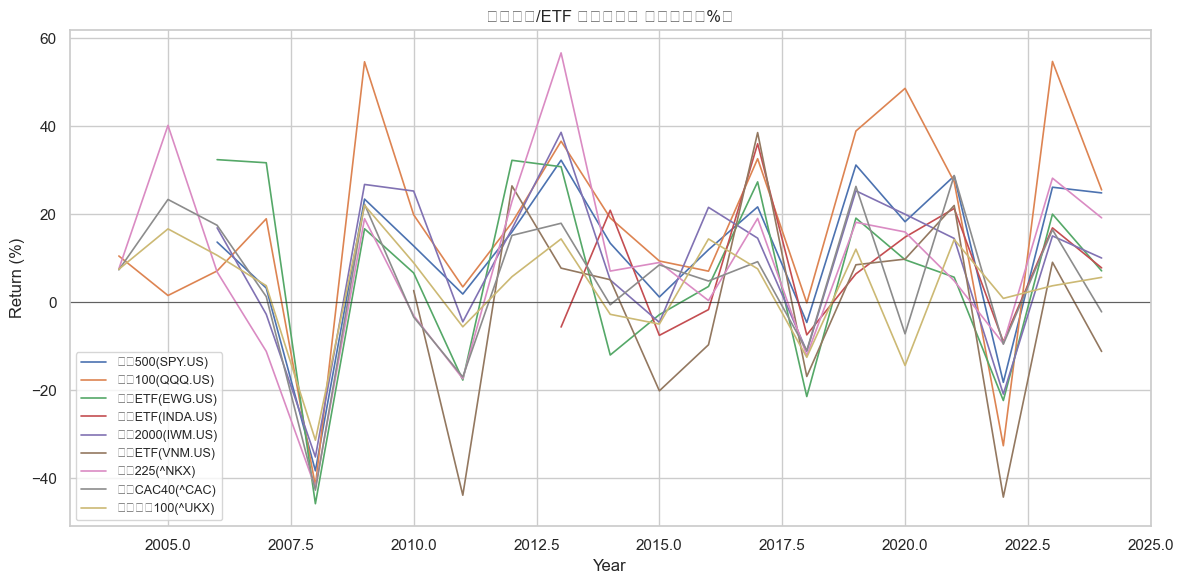

In [2]:
sns.set(style='whitegrid')
OUT = ROOT / 'output' / 'annual_returns_plots'
OUT.mkdir(parents=True, exist_ok=True)

def plot_category(category, df):
    years = sorted([int(c) for c in df.columns])
    fig, ax = plt.subplots(figsize=(12, 6))
    for asset, row in df.iterrows():
        ax.plot(years, row.values.astype(float), lw=1.2, label=str(asset))
    ax.set_title(f'{category} 年度回报（%）')
    ax.set_xlabel('Year')
    ax.set_ylabel('Return (%)')
    ax.axhline(0, color='k', lw=0.8, alpha=0.6)
    if len(df) <= 12:
        ax.legend(loc='best', fontsize=9)
    else:
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=7)
        fig.subplots_adjust(right=0.78)
    fig.tight_layout()
    png = OUT / f"{re.sub(r'[^0-9A-Za-z_.\-\u4e00-\u9fa5]+','_', category)}_lines.png"
    fig.savefig(png, dpi=150)
    plt.show()
    return png

for cat, df in cats:
    display(pd.DataFrame(df))
    plot_category(cat, df)